In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
import fipcore as fpc
import pyspedas
from pyspedas.projects import mms
from pyspedas import get_data, tplot_rename

In [2]:
trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
species = 'e'
bin_width_frac = 0.25

In [3]:
data_dir = os.path.join("..", "data")
subtract_f0 = False
type_tag = 'df' if subtract_f0 else 'f'
probe = '1'
data_rate = 'brst'
level = 'l2'
get_support_data = True
no_update = True
hfile_pref = f'mms{probe}_{data_rate}_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile = os.path.join(data_dir, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))

In [1]:
parapi

NameError: name 'parapi' is not defined

In [4]:
hfile

'../data/mms1_brst_f_e_0.25_20151209_050355_050359.h5'

In [5]:
with h5py.File(hfile, "r") as f:
    ntime = f["meta"]["time"][:]
    bvec_lmn = f["lmn"]["bvec"][:]
    evec_lmn = f["lmn"]["evec_lor"][:]
    evec_fac = f["fac"]["evec_lor"][:]
    jdotE_fac = f["fac"]["jdotE_fac"][:]
    vdf_vol_fac = f["fac"]["bvdf_vol"][...]
    c_vol_fac = f["fac"]["c_vol"][...]
    cz_folds_fac = f["fac"]["cz_folds"][...]
    x_fac = f["fac"]["binc_n"][:]
    y_fac = f["fac"]["binc_n"][:]
    z_fac = f["fac"]["binc_n"][:] 
    vv_fac = f["fac"]["vv"][:] 

In [6]:
ntime.shape, bvec_lmn.shape, evec_lmn.shape, evec_fac.shape, jdotE_fac.shape

((133,), (133, 3), (133, 3), (133, 3), (133, 4))

In [7]:
np.array_equal(evec_lmn, evec_fac)

False

# Reconnection Window Plot

In [8]:
idx = 61
from pyspedas import time_datetime
dt_obj = time_datetime(ntime[idx])
dt_obj0 = time_datetime(ntime[idx-3])
dt_obj1 = time_datetime(ntime[idx+3])

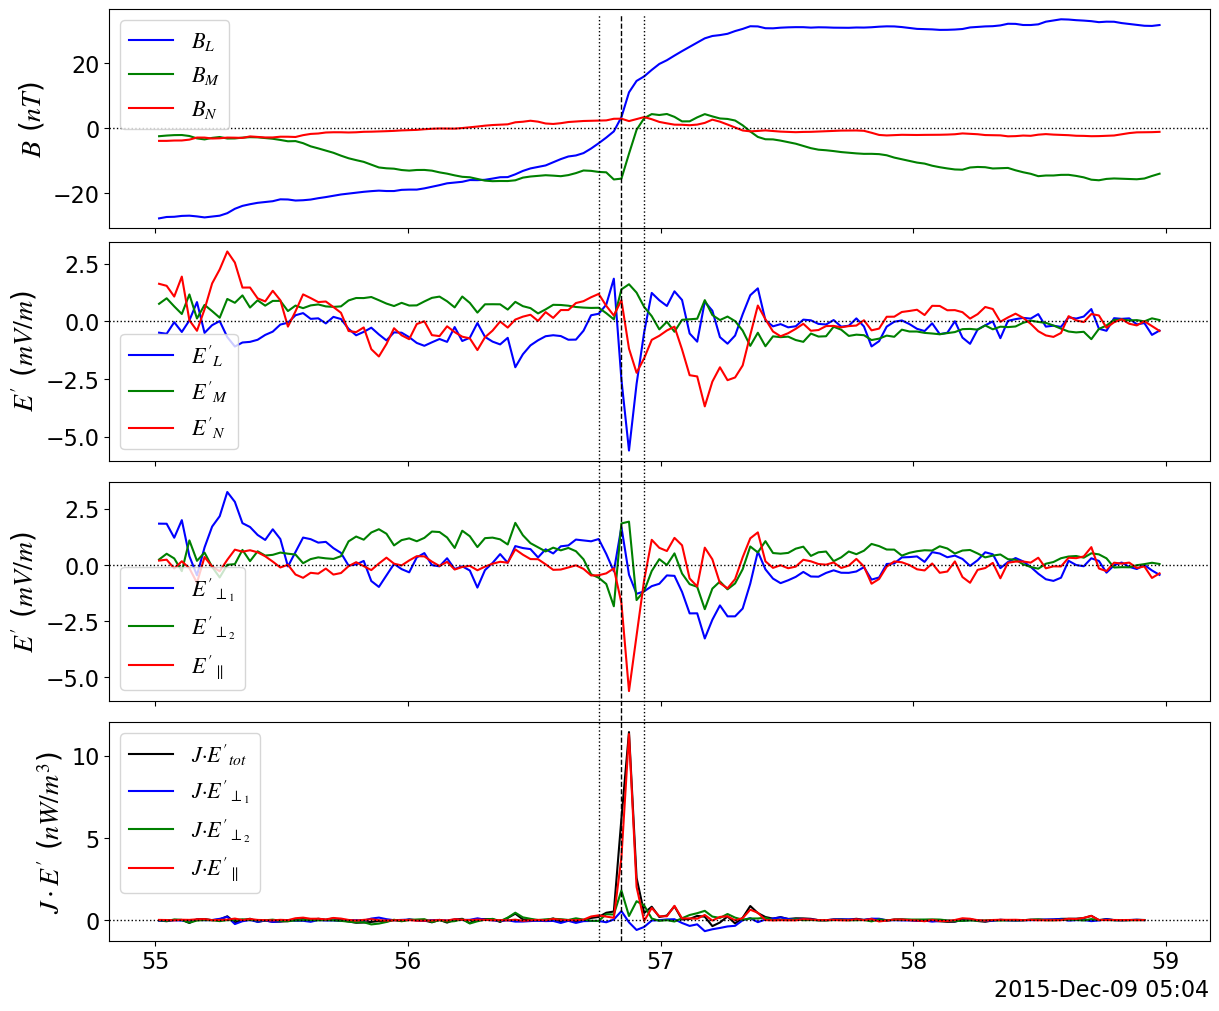

In [ ]:
from pyspedas import time_datetime
import matplotlib.pyplot as plt

t_ax = time_datetime(ntime)
axs_label_fntsz = 20   # adjust as needed
tick_fntsz = 16
legend_fntsz = 16
legendFrame = True

fig, ax = plt.subplots(4,1, figsize=(12, 10), sharex=True, constrained_layout=True)

# First subplot: B vector in LMN coordinates
ax[0].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[0].plot(t_ax, bvec_lmn, linewidth=1.5, label=['$B_L$', '$B_M$', '$B_N$'])
ax[0].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[0].set_ylabel('$B$ ($nT$)', fontsize=axs_label_fntsz)
ax[0].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Second subplot: E vector in LMN coordinates
ax[1].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[1].plot(t_ax, evec_lmn, linewidth=1.5, label=["$E'_L$", "$E'_M$", "$E'_N$"])
ax[1].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[1].set_ylabel("$E'$ ($mV/m$)", fontsize=axs_label_fntsz)
ax[1].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Third subplot: E vector in FAC coordinates
ax[2].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[2].plot(t_ax, evec_fac, linewidth=1.5, label=[r"$E'_{\perp_1}$", r"$E'_{\perp_2}$", 
        r"$E'_{\parallel}$"])
ax[2].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[2].set_ylabel("$E'$ ($mV/m$)", fontsize=axs_label_fntsz)
ax[2].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='lower left')

# Fourth subplot: J.E' in FAC coordinates
ax[3].set_prop_cycle(color=['black', 'blue', 'green', 'red']) # custom color cycle
# Pass 4 labels to match the 4 columns in jdotE_fac
# Pass 4 labels to match the 4 columns in your array
ax[3].plot(t_ax, jdotE_fac, linewidth=1.5, 
    label=[r"$J·E'_{tot}$", r"$J·E'_{\perp_1}$", r"$J·E'_{\perp_2}$", r"$J·E'_{\parallel}$"])
ax[3].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[3].set_ylabel(r"$J \cdot E'$ ($nW/m^3$)", fontsize=axs_label_fntsz)
ax[3].legend(fontsize=legend_fntsz, loc='upper left')

for axis in ax:
    axis.tick_params(axis='both', which='major', labelsize=tick_fntsz)
    axis.xaxis.get_offset_text().set_fontsize(tick_fntsz)  # Scales the date string

# Vertical reference lines
y_up = 4 + 0.228
ax[-1].axvline(x=dt_obj, ymin=0, ymax=y_up, color='k', linestyle='dashed', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj0, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj1, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)

plt.show()

## Adding plasma beta and density to the plot

In [10]:
mms.fgm(trange=trange, probe=probe, data_rate=data_rate, level=level,
        varnames='mms1_fgm_b_gse_brst_l2', time_clip=True, 
        get_support_data=get_support_data, no_update=no_update)
tplot_rename('mms1_fgm_b_gse_brst_l2', 'bvec_gse')

21-Jul-26 12:36:03: Searching for local files...
21-Jul-26 12:36:03: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fgm/brst/l2/2015/12/09/mms1_fgm_brst_l2_20151209050044_v4.22.0.cdf
21-Jul-26 12:36:03: Loading files for group: probe: 1, drate: brst, level: l2, datatype: , after sorting and filtering:
21-Jul-26 12:36:03: /Users/rejohn/Data_Speedas/mms/mms1/fgm/brst/l2/2015/12/09/mms1_fgm_brst_l2_20151209050044_v4.22.0.cdf


In [11]:
mms.fpi(trange= trange, probe=probe, data_rate=data_rate, level='l2',
        datatype=['des-moms', 'dis-moms'], time_clip=True, 
        varnames=['mms1_des_numberdensity_brst', 'mms1_dis_numberdensity_brst', 
        'mms1_des_temppara_brst', 'mms1_des_tempperp_brst', 
        'mms1_dis_temppara_brst', 'mms1_dis_tempperp_brst'], 
        get_support_data=True, no_update=True)
tplot_rename('mms1_des_numberdensity_brst', 'den_e')
tplot_rename('mms1_dis_numberdensity_brst', 'den_i')
tplot_rename('mms1_des_temppara_brst', 'tpara_e')
tplot_rename('mms1_des_tempperp_brst', 'tperp_e')
tplot_rename('mms1_dis_temppara_brst', 'tpara_i')
tplot_rename('mms1_dis_tempperp_brst', 'tperp_i')

21-Jul-26 12:36:03: Searching for local files...
21-Jul-26 12:36:03: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
21-Jul-26 12:36:03: Searching for local files...
21-Jul-26 12:36:03: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
21-Jul-26 12:36:03: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
21-Jul-26 12:36:03: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
21-Jul-26 12:36:03: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dis-moms, after sorting and filtering:
21-Jul-26 12:36:03: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
21-Jul-26 12:36:03: The name mms1_des_errorflags_brst is currently n

In [12]:
fpc.downsample_cad('bvec_gse', 'den_e', trange, newname='bvec_ds')
fpc.upsample_cad('den_i', 'den_e', newname='den_i_us')

21-Jul-26 12:36:03: avg_data was applied to: bvec_ds
21-Jul-26 12:36:03: tinterpol (linear) was applied to: den_i_us


'den_i_us'

In [13]:
_, den_e = get_data('den_e')
_, den_i = get_data('den_i_us')
_, bvec_gse = get_data('bvec_ds')
_, tpara_e = get_data('tpara_e')
_, tperp_e = get_data('tperp_e')
_, tpara_i = get_data('tpara_i')
_, tperp_i = get_data('tperp_i')
bmag = bvec_gse[:, 3]

In [14]:
beta_par_e, beta_perp_e, beta_scalar_e, ntime_e = fpc.compute_beta_profiles(trange)

21-Jul-26 12:36:03: Searching for local files...
21-Jul-26 12:36:03: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
21-Jul-26 12:36:03: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
21-Jul-26 12:36:03: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
21-Jul-26 12:36:03: The name mms1_des_errorflags_brst is currently not in pyspedas
21-Jul-26 12:36:03: The name mms1_des_compressionloss_brst is currently not in pyspedas
21-Jul-26 12:36:03: The name mms1_des_pitchangdist_lowen_brst is currently not in pyspedas
21-Jul-26 12:36:03: The name mms1_des_pitchangdist_miden_brst is currently not in pyspedas
21-Jul-26 12:36:03: The name mms1_des_pitchangdist_highen_brst is currently not in pyspedas
21-Jul-26 12:36:03: The name mms1_des_errorflags_brst_moms is currently not in pyspedas
2

In [15]:
beta_par_i, beta_perp_i, beta_scalar_i, ntime_i = fpc.compute_beta_profiles(trange, species='i')

21-Jul-26 12:36:03: Searching for local files...
21-Jul-26 12:36:03: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
21-Jul-26 12:36:03: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dis-moms, after sorting and filtering:
21-Jul-26 12:36:03: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
21-Jul-26 12:36:03: The name mms1_dis_errorflags_brst is currently not in pyspedas
21-Jul-26 12:36:03: The name mms1_dis_compressionloss_brst is currently not in pyspedas
21-Jul-26 12:36:03: The name mms1_dis_pitchangdist_lowen_brst is currently not in pyspedas
21-Jul-26 12:36:03: The name mms1_dis_pitchangdist_miden_brst is currently not in pyspedas
21-Jul-26 12:36:03: The name mms1_dis_pitchangdist_highen_brst is currently not in pyspedas
21-Jul-26 12:36:03: The name mms1_dis_errorflags_brst_moms is currently not in pyspedas
2

In [27]:
idx = 61
from pyspedas import time_datetime
dt_obj = time_datetime(ntime[idx])
dt_obj0 = time_datetime(ntime[idx-3])
dt_obj1 = time_datetime(ntime[idx+3])

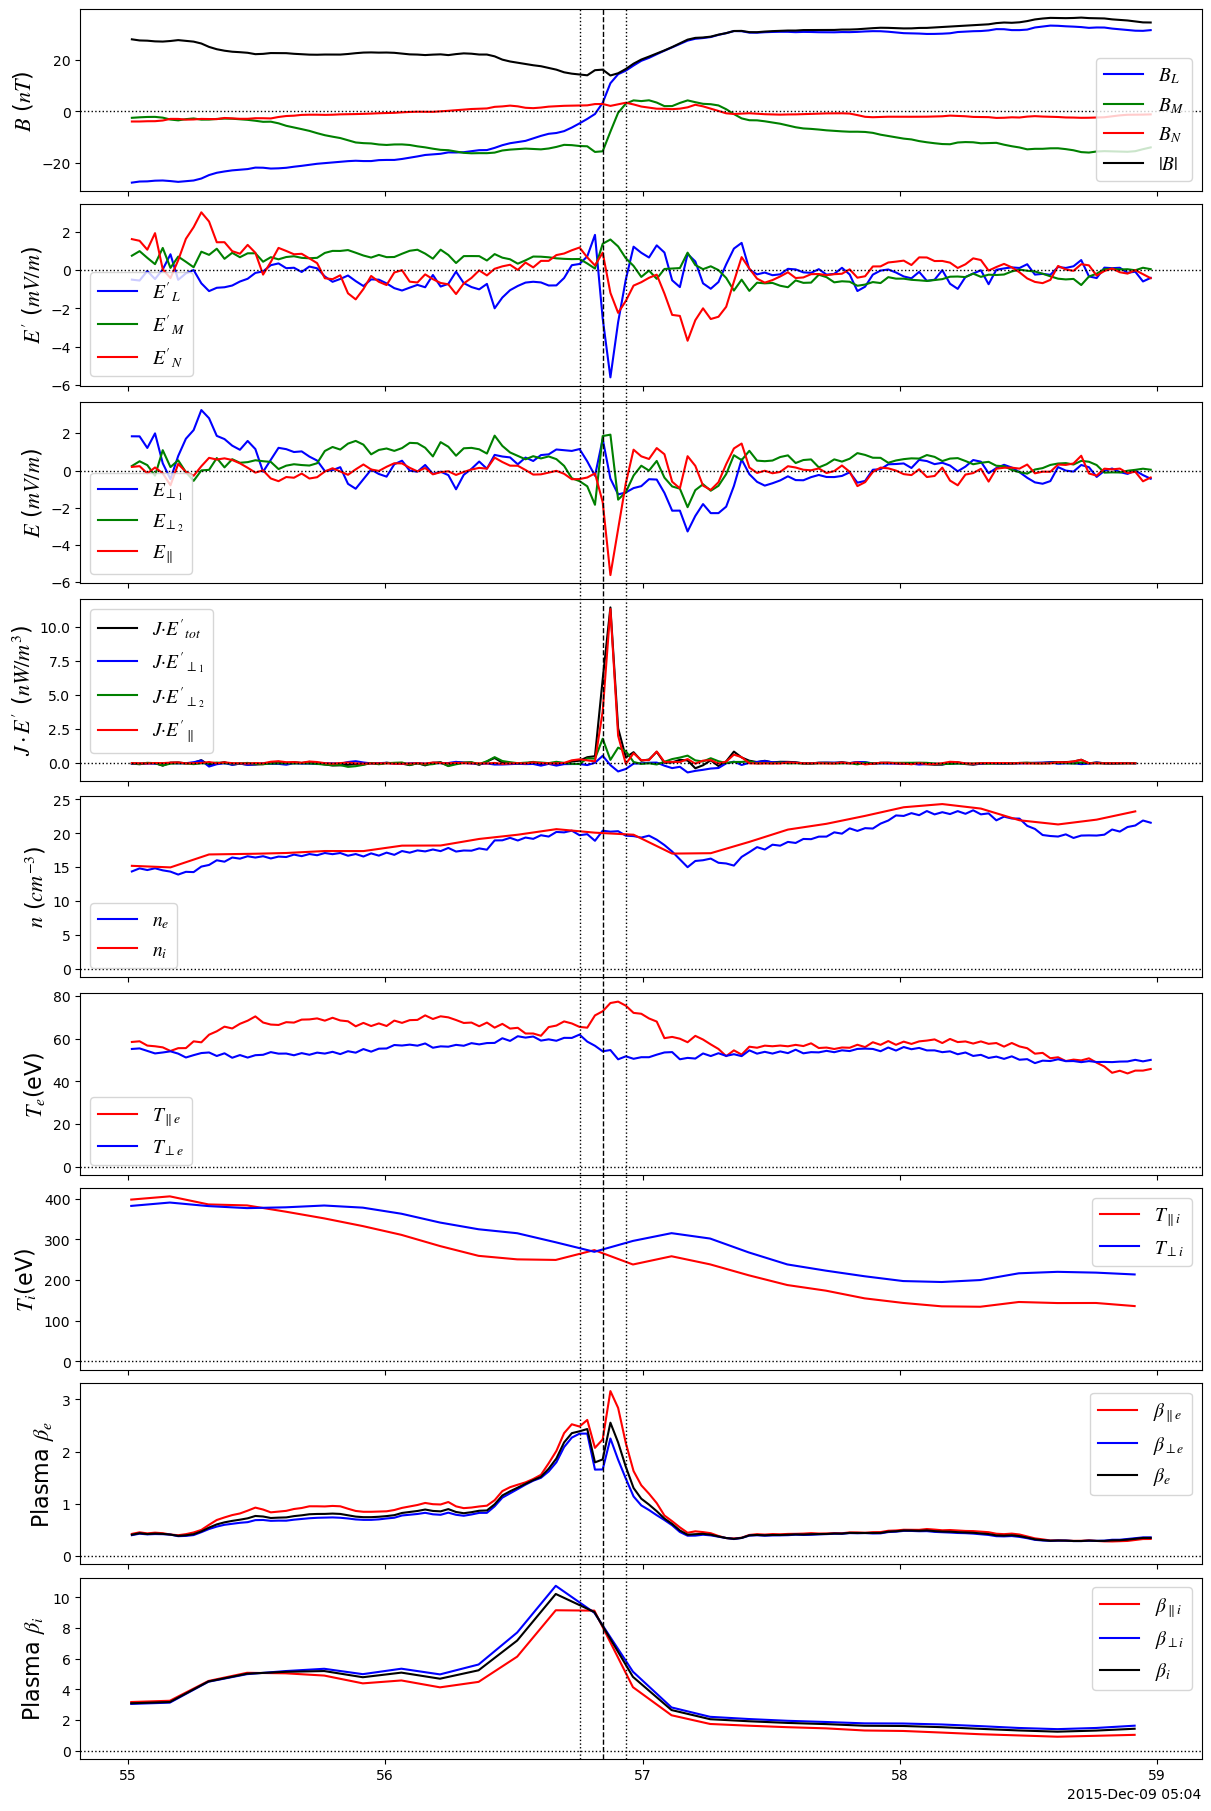

In [17]:
from pyspedas import time_datetime
import matplotlib.pyplot as plt

t_ax = time_datetime(ntime)
axs_label_fntsz = 16   # adjust as needed
legend_fntsz = 14
legendFrame = True

n_subplots = 9
fig, ax = plt.subplots(n_subplots,1, figsize=(12, 18), sharex=True, constrained_layout=True)

# First subplot: B vector in LMN coordinates
ax[0].set_prop_cycle(color=['blue', 'green', 'red', 'black']) # custom color cycle
ax[0].plot(t_ax, bvec_lmn, linewidth=1.5, label=['$B_L$', '$B_M$', '$B_N$'])
ax[0].plot(t_ax, bmag, linewidth=1.5, label='$|B|$')
ax[0].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[0].set_ylabel('$B$ ($nT$)', fontsize=axs_label_fntsz)
ax[0].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Second subplot: E vector in LMN coordinates
ax[1].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[1].plot(t_ax, evec_lmn, linewidth=1.5, label=["$E'_L$", "$E'_M$", "$E'_N$"])
ax[1].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[1].set_ylabel("$E'$ ($mV/m$)", fontsize=axs_label_fntsz)
ax[1].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Third subplot: E vector in FAC coordinates
ax[2].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[2].plot(t_ax, evec_fac, linewidth=1.5, label=[r'$E_{\perp_1}$', r'$E_{\perp_2}$', 
        r'$E_{\parallel}$'])
ax[2].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[2].set_ylabel('$E$ ($mV/m$)', fontsize=axs_label_fntsz)
ax[2].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='lower left')

# Fourth subplot: J.E' in FAC coordinates
ax[3].set_prop_cycle(color=['black', 'blue', 'green', 'red']) # custom color cycle
# Pass 4 labels to match the 4 columns in jdotE_fac
# Pass 4 labels to match the 4 columns in your array
ax[3].plot(t_ax, jdotE_fac, linewidth=1.5, 
    label=[r"$J·E'_{tot}$", r"$J·E'_{\perp_1}$", r"$J·E'_{\perp_2}$", r"$J·E'_{\parallel}$"])
ax[3].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[3].set_ylabel(r"$J \cdot E'$ ($nW/m^3$)", fontsize=axs_label_fntsz)
ax[3].legend(fontsize=legend_fntsz, loc='upper left')

# Fifth subplot: ion and electron density
ax[4].set_prop_cycle(color=['blue', 'red']) # custom color cycle
ax[4].plot(t_ax, den_e, linewidth=1.5, label=r'$n_e$')
ax[4].plot(t_ax, den_i, linewidth=1.5, label=r'$n_i$')
ax[4].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[4].set_ylabel('$n$ ($cm^{-3}$)', fontsize=axs_label_fntsz)
ax[4].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Sixth subplot: electron temp profiles
ax[5].set_prop_cycle(color=['red', 'blue']) # custom color cycle
ax[5].plot(t_ax, tpara_e, linewidth=1.5, label=r'$T_{\parallel e}$')
ax[5].plot(t_ax, tperp_e, linewidth=1.5, label=r'$T_{\perp e}$')
ax[5].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[5].set_ylabel(r'$T_e$(eV)', fontsize=axs_label_fntsz)
ax[5].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Seventh subplot: ion temp profiles
t_axi = time_datetime(ntime_i)
ax[6].set_prop_cycle(color=['red', 'blue']) # custom color cycle
ax[6].plot(t_axi, tpara_i, linewidth=1.5, label=r'$T_{\parallel i}$')
ax[6].plot(t_axi, tperp_i, linewidth=1.5, label=r'$T_{\perp i}$')
ax[6].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[6].set_ylabel(r'$T_i$(eV)', fontsize=axs_label_fntsz)
ax[6].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Eighth subplot: electron beta profiles
ax[7].set_prop_cycle(color=['red', 'blue', 'black']) # custom color cycle
ax[7].plot(t_ax, beta_par_e, linewidth=1.5, label=r'$\beta_{\parallel e}$')
ax[7].plot(t_ax, beta_perp_e, linewidth=1.5, label=r'$\beta_{\perp e}$')
ax[7].plot(t_ax, beta_scalar_e, linewidth=1.5, label=r'$\beta_{e}$')
ax[7].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[7].set_ylabel(r'Plasma $\beta_e$', fontsize=axs_label_fntsz)
ax[7].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Ninth subplot: ion beta profiles
ax[8].set_prop_cycle(color=['red', 'blue', 'black']) # custom color cycle
ax[8].plot(t_axi, beta_par_i, linewidth=1.5, label=r'$\beta_{\parallel i}$')
ax[8].plot(t_axi, beta_perp_i, linewidth=1.5, label=r'$\beta_{\perp i}$')
ax[8].plot(t_axi, beta_scalar_i, linewidth=1.5, label=r'$\beta_{i}$')
ax[8].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[8].set_ylabel(r'Plasma $\beta_i$', fontsize=axs_label_fntsz)
ax[8].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Vertical reference lines
y_up = n_subplots + 0.64
ax[-1].axvline(x=dt_obj, ymin=0, ymax=y_up, color='k', linestyle='dashed', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj0, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj1, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)


plt.show()

## Adding velocities to the plot

In [18]:
fpi_vars = mms.fpi(trange=trange, datatype=['des-moms'], level='l2', 
                            data_rate='brst', varnames=['mms1_des_bulkv_gse_brst'],
                            time_clip=True)

21-Jul-26 12:36:04: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
21-Jul-26 12:36:04: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
21-Jul-26 12:36:04: The name mms1_des_errorflags_brst is currently not in pyspedas
21-Jul-26 12:36:04: The name mms1_des_compressionloss_brst is currently not in pyspedas
21-Jul-26 12:36:04: The name mms1_des_pitchangdist_lowen_brst is currently not in pyspedas
21-Jul-26 12:36:04: The name mms1_des_pitchangdist_miden_brst is currently not in pyspedas
21-Jul-26 12:36:04: The name mms1_des_pitchangdist_highen_brst is currently not in pyspedas
21-Jul-26 12:36:04: The name mms1_des_errorflags_brst_moms is currently not in pyspedas
21-Jul-26 12:36:04: The name mms1_des_errorflags_brst_moms is currently not in pyspedas
21-Jul-26 12:36:04: The name mms1_des_compressionloss_brst_moms is currently not in pyspedas
21-Jul-26 12:36:04

In [19]:
pyspedas.tplot_rename('mms1_des_bulkv_gse_brst', 'bulk_ve_gse')

In [36]:
with h5py.File(hfile, "r") as f:
    fac_mat = f["fac"]['rot_mat'][...]
    lmn_mat = f["lmn"]['rot_mat'][...]

In [37]:
_, bulk_ve_gse = get_data('bulk_ve_gse')

In [40]:
bulk_ve_fac = np.einsum('tij, tj -> ti', fac_mat, bulk_ve_gse)

In [44]:
lmn_mat.shape

(1, 3, 3)

In [45]:
bulk_ve_lmn = np.einsum('ij, tj -> ti', lmn_mat[0], bulk_ve_gse)

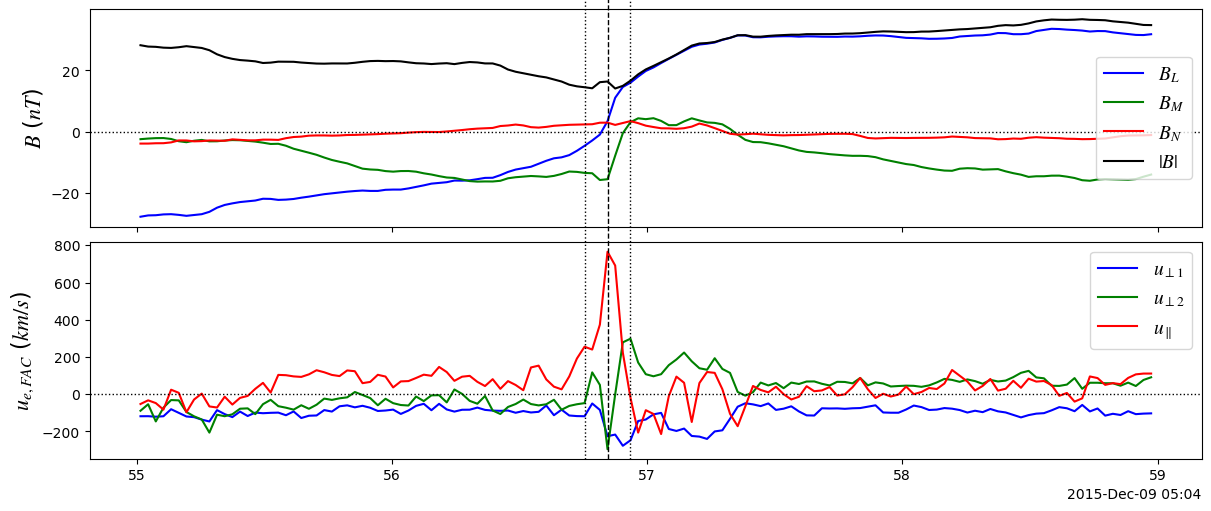

In [32]:
from pyspedas import time_datetime
import matplotlib.pyplot as plt

t_ax = time_datetime(ntime)
axs_label_fntsz = 16   # adjust as needed
legend_fntsz = 14
legendFrame = True

n_subplots = 2
fig, ax = plt.subplots(n_subplots,1, figsize=(12, 5), sharex=True, constrained_layout=True)

# First subplot: B vector in LMN coordinates
ax[0].set_prop_cycle(color=['blue', 'green', 'red', 'black']) # custom color cycle
ax[0].plot(t_ax, bvec_lmn, linewidth=1.5, label=['$B_L$', '$B_M$', '$B_N$'])
ax[0].plot(t_ax, bmag, linewidth=1.5, label='$|B|$')
ax[0].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[0].set_ylabel('$B$ ($nT$)', fontsize=axs_label_fntsz)
ax[0].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Second subplot: E vector in LMN coordinates
ax[1].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[1].plot(t_ax, bulk_ve_fac, linewidth=1.5, label=[r"$u_{\perp 1}$", 
    r"$u_{\perp 2}$", r"$u_{\parallel}$"])
ax[1].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[1].set_ylabel("$u_{e, FAC}$ ($km/s$)", fontsize=axs_label_fntsz)
ax[1].legend(fontsize=legend_fntsz, frameon=legendFrame)


# Vertical reference lines
y_up = n_subplots + 0.64
ax[-1].axvline(x=dt_obj, ymin=0, ymax=y_up, color='k', linestyle='dashed', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj0, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj1, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)


plt.show()

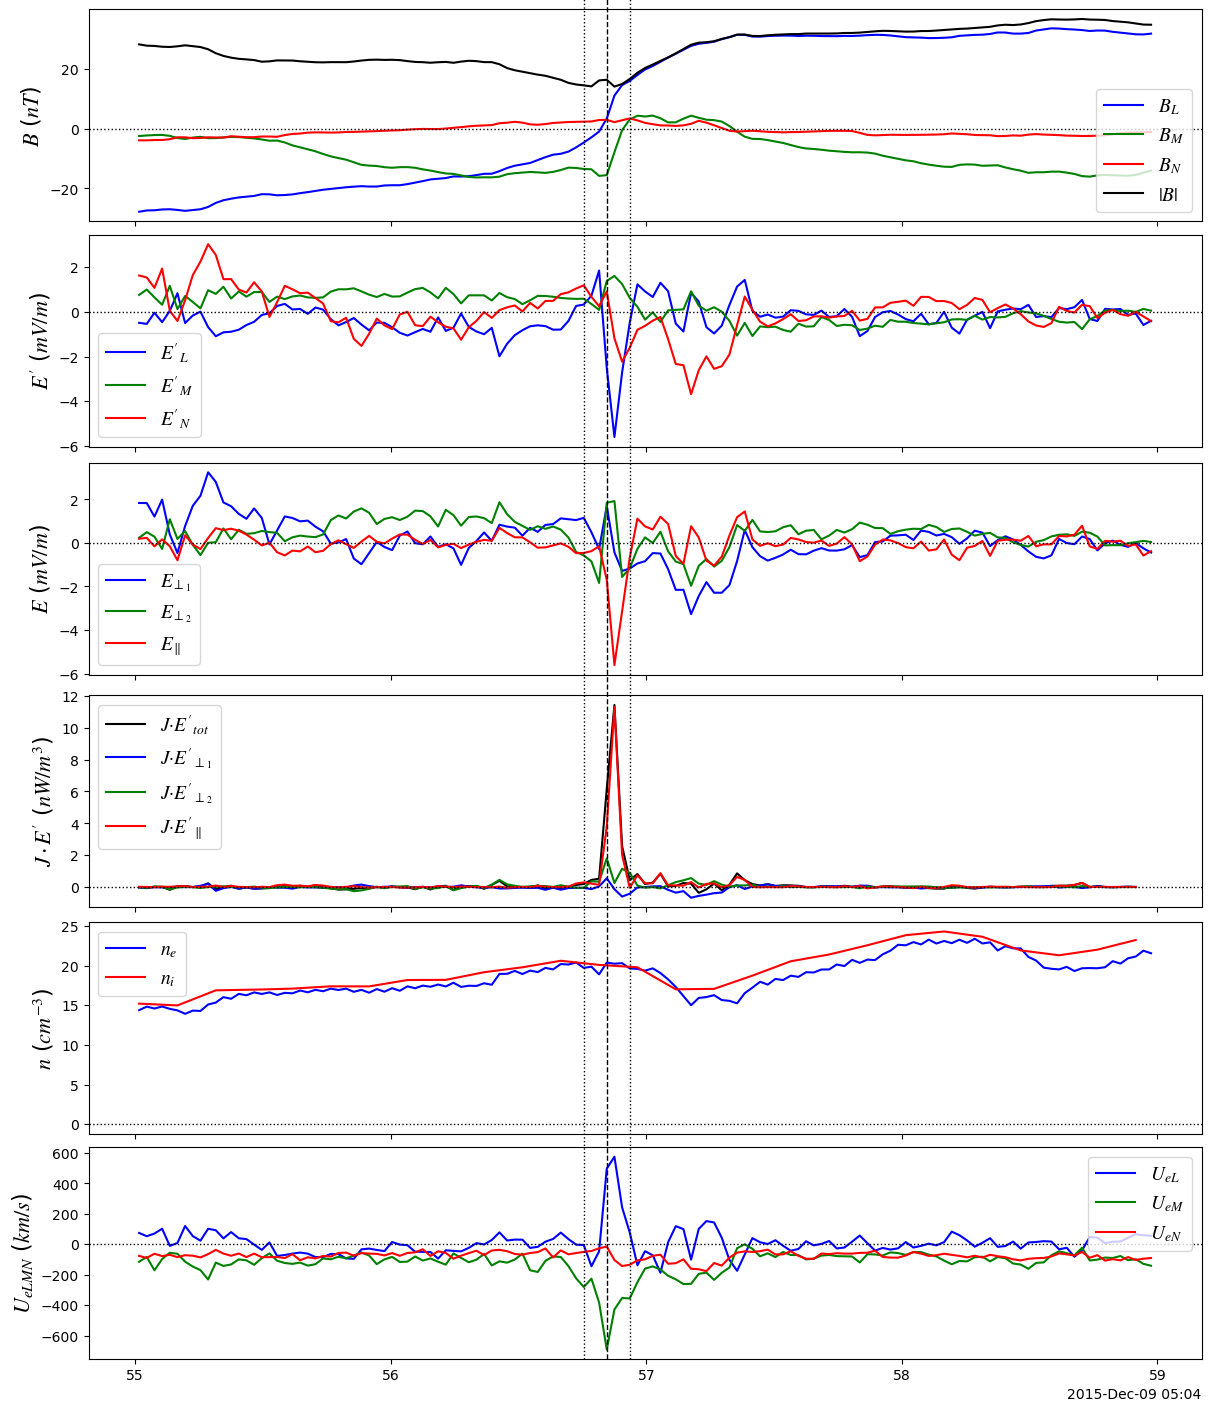

In [52]:
from pyspedas import time_datetime
import matplotlib.pyplot as plt

t_ax = time_datetime(ntime)
axs_label_fntsz = 16   # adjust as needed
legend_fntsz = 14
legendFrame = True

n_subplots = 6
fig, ax = plt.subplots(n_subplots,1, figsize=(12, 14), sharex=True, constrained_layout=True)

# First subplot: B vector in LMN coordinates
ax[0].set_prop_cycle(color=['blue', 'green', 'red', 'black']) # custom color cycle
ax[0].plot(t_ax, bvec_lmn, linewidth=1.5, label=['$B_L$', '$B_M$', '$B_N$'])
ax[0].plot(t_ax, bmag, linewidth=1.5, label='$|B|$')
ax[0].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[0].set_ylabel('$B$ ($nT$)', fontsize=axs_label_fntsz)
ax[0].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Second subplot: E vector in LMN coordinates
ax[1].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[1].plot(t_ax, evec_lmn, linewidth=1.5, label=["$E'_L$", "$E'_M$", "$E'_N$"])
ax[1].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[1].set_ylabel("$E'$ ($mV/m$)", fontsize=axs_label_fntsz)
ax[1].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Third subplot: E vector in FAC coordinates
ax[2].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[2].plot(t_ax, evec_fac, linewidth=1.5, label=[r'$E_{\perp_1}$', r'$E_{\perp_2}$', 
        r'$E_{\parallel}$'])
ax[2].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[2].set_ylabel('$E$ ($mV/m$)', fontsize=axs_label_fntsz)
ax[2].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='lower left')

# Fourth subplot: J.E' in FAC coordinates
ax[3].set_prop_cycle(color=['black', 'blue', 'green', 'red']) # custom color cycle
# Pass 4 labels to match the 4 columns in jdotE_fac
# Pass 4 labels to match the 4 columns in your array
ax[3].plot(t_ax, jdotE_fac, linewidth=1.5, 
    label=[r"$J·E'_{tot}$", r"$J·E'_{\perp_1}$", r"$J·E'_{\perp_2}$", r"$J·E'_{\parallel}$"])
ax[3].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[3].set_ylabel(r"$J \cdot E'$ ($nW/m^3$)", fontsize=axs_label_fntsz)
ax[3].legend(fontsize=legend_fntsz, loc='upper left')

# Fifth subplot: ion and electron density
ax[4].set_prop_cycle(color=['blue', 'red']) # custom color cycle
ax[4].plot(t_ax, den_e, linewidth=1.5, label=r'$n_e$')
ax[4].plot(t_ax, den_i, linewidth=1.5, label=r'$n_i$')
ax[4].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[4].set_ylabel('$n$ ($cm^{-3}$)', fontsize=axs_label_fntsz)
ax[4].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Sixth subplot: electron bulkve_lmn profiles
ax[5].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[5].plot(t_ax, bulk_ve_lmn, linewidth=1.5, label=["$U_{eL}$", "$U_{eM}$", "$U_{eN}$"])
ax[5].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[5].set_ylabel("$U_{eLMN}$ ($km/s$)", fontsize=axs_label_fntsz)
ax[5].legend(fontsize=legend_fntsz, frameon=legendFrame)


# Vertical reference lines
y_up = n_subplots + 0.64
ax[-1].axvline(x=dt_obj, ymin=0, ymax=y_up, color='k', linestyle='dashed', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj0, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj1, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)


plt.show()

# VDF Plot for t=62, the reconnection time

In [24]:
vdf_vol_fac.shape

(28, 28, 28, 133)

In [25]:
vdf_12, vdf_23, vdf_13 = fpc.slice3d_to_2d(vdf_vol_fac, time_slice=62)

In [26]:
vdf_fac_list = (vdf_12, vdf_13, vdf_23.T) # The order is xy, xz and zy
ax_pairs = ((x_fac, y_fac), (x_fac, z_fac), (z_fac, y_fac))
ax_lbls = [r"$v_{\perp 1}/v_{te}$", r"$v_{\perp 2}/v_{te}$", 
                           r"$v_{\parallel}/v_{te}$"]
axlabel_pairs = ((ax_lbls[0], ax_lbls[1]), (ax_lbls[0], ax_lbls[2]), 
                    (ax_lbls[2], ax_lbls[1])) # xy, xz, zy

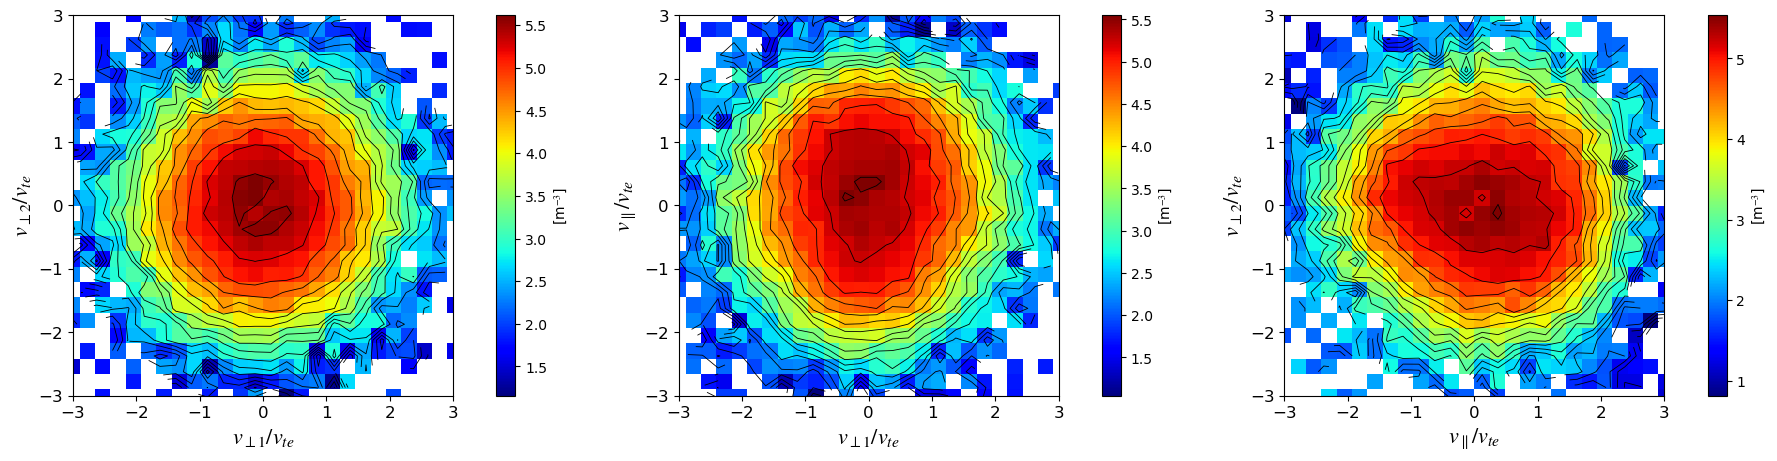

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), dpi=100, constrained_layout=True)
axis_fntsz = 16
cbar_ht=0.047

for i in range(3):
    vmin, vmax = fpc.global_vmin_vmax_vdf(vdf_fac_list[i])
    ax1, ax2 = ax_pairs[i]
    xlabel, ylabel = axlabel_pairs[i]
    im1, _ = fpc.imagecont_vdf(ax1, ax2, vdf_fac_list[i], xlabel=xlabel, 
                ylabel=ylabel, ax=axes[i], vmin=vmin, vmax=vmax, 
                axis_fntsz=axis_fntsz)
    height, width = len(ax2), len(ax1)
    cbar = fig.colorbar(im1, ax=axes[i], fraction=cbar_ht*height/width, pad=0.08)
    cbar.set_label(r"[m$^{-3}$]")

# Folded E-parallel FPC plot for t=62, the reconnection event

In [39]:
c_vol_fac.shape, cz_folds_fac.shape

((3, 28, 28, 28, 133), (2, 28, 28, 133))

In [40]:
cz_12, cz_23, cz_13 = fpc.slice3d_to_2d(c_vol_fac[2], time_slice=62)

In [41]:
cz_fac_list = (cz_12, cz_folds_fac[0, :, :, 62], cz_folds_fac[1, :, :, 62]) # The order is xy, xz and zy   

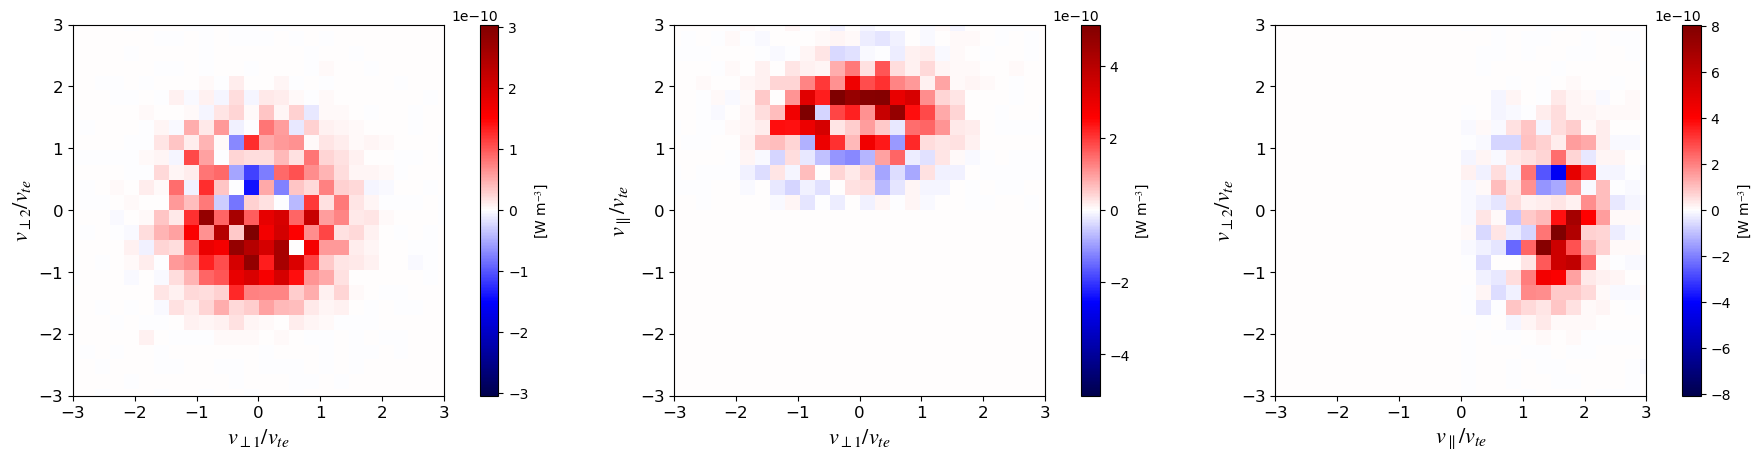

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), dpi=100, constrained_layout=True)
axis_fntsz = 16
cbar_ht=0.047

for i in range(3):
    vmin, vmax = fpc.global_vmin_vmax_fpc(cz_fac_list[i])
    ax1, ax2 = ax_pairs[i]
    xlabel, ylabel = axlabel_pairs[i]
    im2, _ = fpc.imagecont_fpc(ax1, ax2, cz_fac_list[i], xlabel=xlabel, 
                ylabel=ylabel, ax=axes[i], vmin=vmin, vmax=vmax, 
                axis_fntsz=axis_fntsz)
    height, width = len(ax2), len(ax1)
    cbar = fig.colorbar(im2, ax=axes[i], fraction=cbar_ht*height/width, pad=0.005)
    cbar.set_label(r"[W m$^{-3}$]")


# Subtracted FPC integrated

In [6]:
data_dir = os.path.join("..", "data")
subtract_f0 = True
type_tag = 'df' if subtract_f0 else 'f'
probe = '1'
data_rate = 'brst'
level = 'l2'
get_support_data = True
no_update = True
hfile_pref = f'mms{probe}_{data_rate}_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile_df = os.path.join(data_dir, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))

In [7]:
hfile_df

'../data/mms1_brst_df_e_0.25_20151209_050355_050359.h5'

In [28]:
with h5py.File(hfile_df, 'r') as f:
    print(f['fac'].keys())

<KeysViewHDF5 ['Cprime_raw', 'Cprime_vol', 'JE_tot', 'bCprime_avg', 'bCprime_vol', 'binc', 'binc_n', 'bvdf_avg', 'bvdf_vol', 'c_avg', 'c_vol', 'edges', 'edges_n', 'evec_lor', 'npts_vol', 'npts_vol_cp', 'rot_mat', 'vdf_eq', 'vmap', 'vv']>


In [32]:
with h5py.File(hfile_df, "r") as f:
    ntime = f["meta"]["time"][:]
    c_vol_fac = f["fac"]["c_vol"][...]
    dvdf_vol_fac = f["fac"]["bvdf_vol"][...]
    vpar_fac = f["fac"]["binc_n"][:]
    vv_fac = f["fac"]["vv"][:] 

In [33]:
c_vol_fac.shape, vpar_fac.shape, dvdf_vol_fac.shape

((3, 28, 28, 28, 133), (28,), (28, 28, 28, 133))

Only selecting the parallel component of the FPC signature:

In [19]:
c_vol_fac_par = c_vol_fac[2]

In [20]:
c_vol_fac_par_t62 = c_vol_fac_par[:, :, :, 62]

In [21]:
c_vol_fac_par_t62.shape

(28, 28, 28)

integrating over both perp directions

In [22]:
c_line_fac_par_t62 = np.nansum(c_vol_fac_par_t62, axis=(0, 1))

In [23]:
c_line_fac_par_t62.shape

(28,)

In [24]:
vv_fac.shape

(3, 16384, 133)

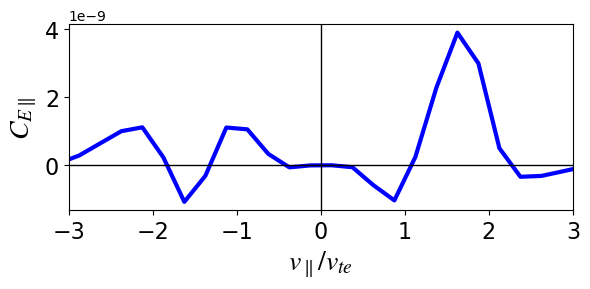

In [41]:
import matplotlib.pyplot as plt

# Assuming you have arrays:
# vpar_norm  → normalized parallel velocity (same scale as v_parallel/v_te)
# C_line     → integrated C_E_parallel array (shape = (28,))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(vpar_fac, c_line_fac_par_t62, color='blue', linewidth=3)

# Axis labels
ax.set_xlabel(r'$v_{\parallel}/v_{te}$', fontsize=20)
ax.set_ylabel(r'$C_{E\parallel}$', fontsize=20)

# Style tweaks to match the reference plot
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.tick_params(labelsize=16)
ax.set_xlim([-3, 3])

plt.tight_layout()
plt.show()

## Subtract vdf integrated
Selecting the subtracted vdf for t = 62

In [37]:
dvdf_vol_fac_t62 = dvdf_vol_fac[:, :, :, 62]

In [38]:
dvdf_vol_fac_t62.shape

(28, 28, 28)

Integrating over both perp directions

In [39]:
dvdf_line_fac_par_t62 = np.nansum(dvdf_vol_fac_t62, axis=(0, 1))

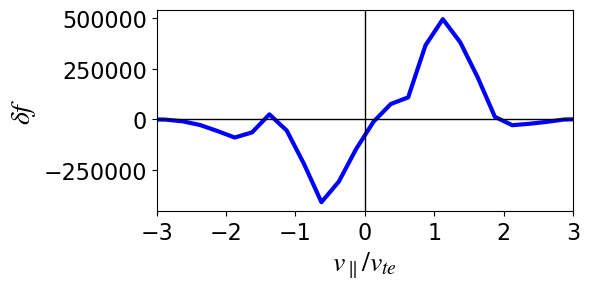

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have arrays:
# vpar_norm  → normalized parallel velocity (same scale as v_parallel/v_te)
# dvdf_line  → integrated df_parallel array (shape = (28,))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(vpar_fac, dvdf_line_fac_par_t62, color='blue', linewidth=3)

# Axis labels
ax.set_xlabel(r'$v_{\parallel}/v_{te}$', fontsize=20)
ax.set_ylabel(r'$\delta f$', fontsize=20)

# Style tweaks to match the reference plot
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.tick_params(labelsize=16)
ax.set_xlim([-3, 3])

plt.tight_layout()
plt.show()